# Análisis Bibliométrico General

**INPUT**: base de datos descargada de Scopus en formato CSV que contiene 5.470 artículos científicos de los últimos 10 años sobre Riego de Precisión, IA, Teledetección y Toma de Decisiones

## Librerías usadas

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import itertools
import networkx as nx
import nltk
from nltk.corpus import stopwords
import re

## Lectura de datos

In [2]:
articulos = pd.read_csv('scopus.csv')

## Exploración de datos

In [3]:
articulos.head()

,Authors,Author full names,Author(s) ID,Title,Year,Source title,Volume,Issue,Art. No.,Page start,...,Cited by,DOI,Link,Abstract,Author Keywords,Index Keywords,Document Type,Publication Stage,Open Access,Source
0,Wang Y.; Wang X.; Hui H.; Pian K.,"Wang, Yanying (59654030000)""; Wang, Xianzhi (5...","59654030000"";58773984700;55511318200;"" 6032172...",Agricultural water savings and productivity re...,2026,Agricultural Water Management,330,NaN,110409,NaN,...,0,10.1016/j.agwat.2026.110409,https://www.scopus.com/pages/publications/1050...,Groundwater depletion driven by irrigated agri...,"Agricultural water use""; Groundwater governanc...","China""; North China Plain; Groundwater; Ground...",Article,Final,"All Open Access""; Gold Open Access;"" Green Ope...",Scopus
1,Mahmoud A.K.; El-Gindy A.M.,"Mahmoud, Amr K. (57211145403)"";"" El-Gindy, A.M...","57211145403"";"" 59024784900",Smart Application Designed for Precision and S...,2026,Agricultural Research,15,2,NaN,1244,...,0,10.1007/s40003-025-00931-x,https://www.scopus.com/pages/publications/1050...,"A smart Android application, Olive ET Tracker ...","Olive tree""; Reference evapotranspiration; Sap...","Egypt""; Matruh [Egypt]; Riyadh [Riyadh (PRV)];...",Article,Final,NaN,Scopus
2,Moisa M.B.; Iticha B.; Chalchissa F.B.; Roba Z...,"Moisa, Mitiku Badasa (57226855091)""; Iticha, B...","57226855091"";57201382482;57451650100;578760972...",Mapping the Spatiotemporal Nexus of Soil Moist...,2026,Earth Systems and Environment,10,6,NaN,7657,...,0,10.1007/s41748-025-01007-0,https://www.scopus.com/pages/publications/1050...,Expansion of surface irrigation has an effect ...,"Irrigation management""; LULC; Moisture index; ...",NaN,Article,Final,NaN,Scopus
3,Zhao S.; Ding J.; Wang J.; Han L.; Han H.; Wan...,"Zhao, Shuang (57567633500)""; Ding, Jianli (136...","57567633500"";13610395400;60415919700;572189926...",Estimating surface soil salinity and water–hea...,2026,Soil and Tillage Research,262,NaN,107223,NaN,...,0,10.1016/j.still.2026.107223,https://www.scopus.com/pages/publications/1050...,Under the dual pressures of climate change and...,"Coupling coordination""; Landsat-8; Sentinel-1;...","Arid regions""; Climate change; Drought; Ecosys...",Article,Final,NaN,Scopus
4,Li M.; Lei H.; Li F.; Huang J.; Shi Y.; Xu S.;...,"Li, Mingyang (57205588963)""; Lei, Huimin (1683...","57205588963"";16836656500;57206890117;606377769...",CWN-Net: a precise segmentation model for comp...,2026,Journal of Hydrology,676,NaN,135666,NaN,...,0,10.1016/j.jhydrol.2026.135666,https://www.scopus.com/pages/publications/1050...,Precise segmentation of composite water networ...,"Boundary-sensitive dual-branch architecture""; ...","China""; Shandong; Banks (bodies of water); Cha...",Article,Final,NaN,Scopus


In [4]:
articulos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5468 entries, 0 to 5467
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Authors            5468 non-null   object
 1   Author full names  5468 non-null   object
 2   Author(s) ID       5468 non-null   object
 3   Title              5468 non-null   object
 4   Year               5468 non-null   int64 
 5   Source title       5468 non-null   object
 6   Volume             5389 non-null   object
 7   Issue              3414 non-null   object
 8   Art. No.           3540 non-null   object
 9   Page start         1909 non-null   object
 10  Page end           1909 non-null   object
 11  Cited by           5467 non-null   object
 12  DOI                5337 non-null   object
 13  Link               5468 non-null   object
 14  Abstract           5468 non-null   object
 15  Author Keywords    5144 non-null   object
 16  Index Keywords     3965 non-null   object


In [7]:
articulos.columns

Index(['Authors', 'Author full names', 'Author(s) ID', 'Title', 'Year',
       'Source title', 'Volume', 'Issue', 'Art. No.', 'Page start', 'Page end',
       'Cited by', 'DOI', 'Link', 'Abstract', 'Author Keywords',
       'Index Keywords', 'Document Type', 'Publication Stage', 'Open Access',
       'Source'],
      dtype='object')

## **Evolución Temporal**: Gráfico de publicaciones por año (2016 - 2026).

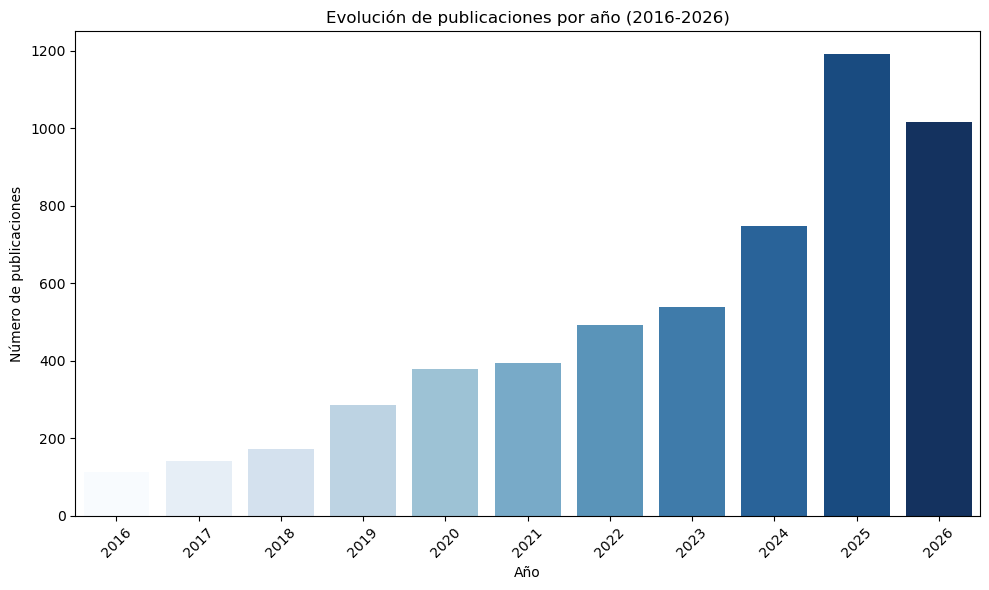

In [8]:
# Filtrar años relevantes
df_filtrado = articulos[(articulos['Year'] >= 2016) & (articulos['Year'] <= 2026)]

# Contar publicaciones por año
conteo = df_filtrado['Year'].value_counts().sort_index()

# Convertir a DataFrame
df_conteo = conteo.reset_index()
df_conteo.columns = ['Year', 'Publicaciones']

plt.figure(figsize=(10,6))
sns.barplot(
    data=df_conteo,
    x='Year',
    y='Publicaciones',
    hue='Year',          # asignar hue explícitamente
    palette='Blues',
    legend=False         # ocultar leyenda redundante
)
plt.title("Evolución de publicaciones por año (2016-2026)")
plt.xlabel("Año")
plt.ylabel("Número de publicaciones")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## **Top 10 Revistas y Países**: Identificar los diarios científicos (journals) de mayor impacto y los países líderes en la temática

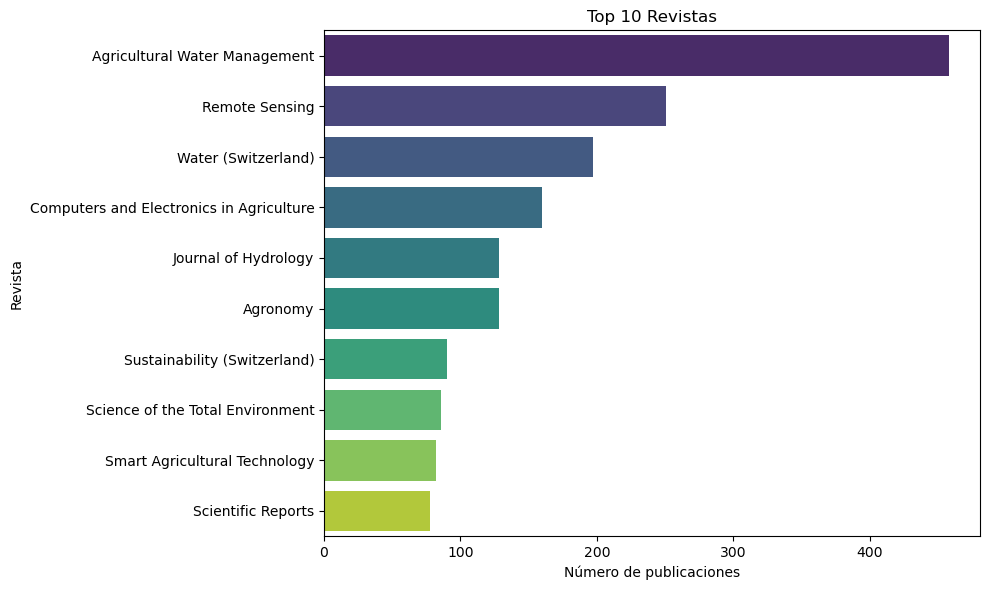

In [9]:
# --- Top 10 Revistas ---
top_revistas = articulos['Source title'].value_counts().head(10)

df_revistas = top_revistas.reset_index()
df_revistas.columns = ['Revista', 'Publicaciones']

plt.figure(figsize=(10,6))
sns.barplot(
    data=df_revistas,
    x='Publicaciones',
    y='Revista',
    hue='Revista',       # asignar hue explícitamente
    palette='viridis',
    legend=False         # ocultar leyenda redundante
)
plt.title("Top 10 Revistas")
plt.xlabel("Número de publicaciones")
plt.ylabel("Revista")
plt.tight_layout()
plt.show()

In [10]:
# --- Top 10 Países ---
# Ausencia del dato

## **Red de Co-citación**: Mapear los autores y papers clásicos más citados de la muestra (los "infaltables" de nuestra bibliografía).

No entiendo con que columnas se deberia trabajar

## Minería de Texto y Nube de Co-ocurrencia de Palabras Clave (Keywords)

* Procesar los campos Author Keywords e Index Keywords (extrayendo stop-words)
* Generar un mapa de red de palabras clave (Cluster Map / VOSviewer) para ver cómo se agrupa la literatura actual (ej. Cluster 1: IoT/Sensores, Cluster 2: Satélite/ET, Cluster 3: Machine Learning/Predicción)

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/ppando/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Cluster 1: ['radars', 'magnet', 'thermocouples', 'music', 'cognition', 'stakeholders"', 'market', 'canfis', 'chili', 'l"']
Cluster 2: ['yura', 'perceptron’s', 'intensification', 'identifications', 'south-to-north', 'helmand', 'yarmouk', 'water-managers', 'physically', 'mongolia']
Cluster 3: ['frutescens', 'oxycodone', 'willingness-to-accept', 'offs', 'qarqan', '[spain]', 'rivers"', 'feed-forward', 'phosphate"', 'sahara"']
Cluster 4: ['hypochlorite', 'epinephrine', 'apical', 'cellulitis', 'retreatment', 'percha', 'acid"', 'preoperative', 'chloraxid', 'rhizophagus']
Cluster 5: ['cryptosporidiosis', 'animalia', 'surface/drinking', 'health-based', 'lamb', 'outbreaks', '(qmra)', 'cryptosporidium', 'oocyst', 'pathogens']


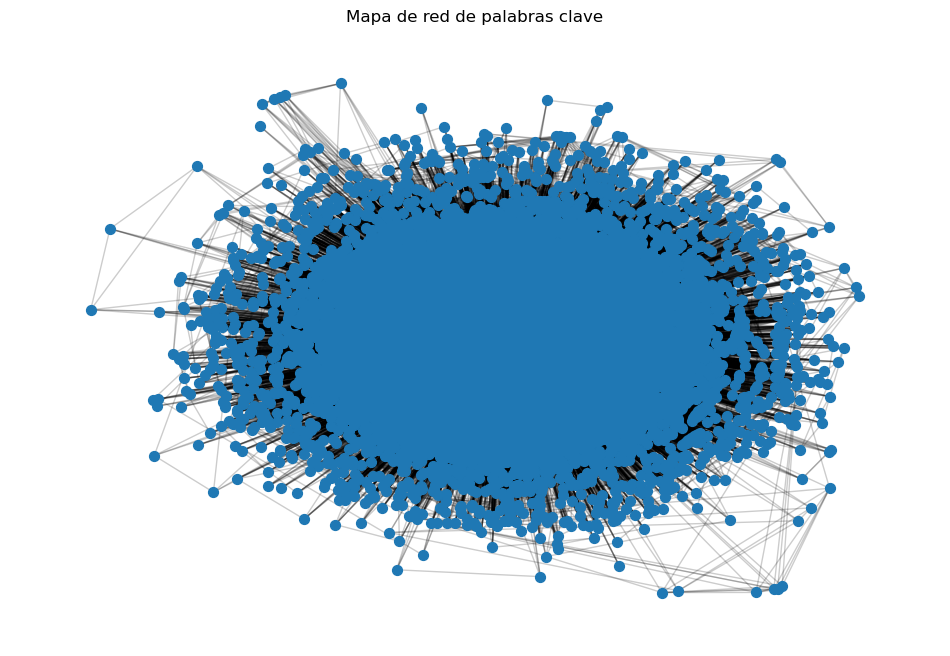

In [12]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english')) | set(stopwords.words('spanish'))

# Leer archivo
articulos = pd.read_csv("scopus.csv")

# Combinar columnas
articulos['Keywords'] = (
    articulos['Author Keywords'].fillna('') + ';' +
    articulos['Index Keywords'].fillna('')
)

# Limpiar y tokenizar
def limpiar_keywords(texto):
    tokens = re.split(r';|,|\s+', texto.lower())
    tokens = [t.strip() for t in tokens if t and t not in stop_words]
    return tokens

articulos['Keywords_clean'] = articulos['Keywords'].apply(limpiar_keywords)

# Construir grafo de co-ocurrencia
G = nx.Graph()
for kws in articulos['Keywords_clean']:
    for kw1, kw2 in itertools.combinations(set(kws), 2):
        if G.has_edge(kw1, kw2):
            G[kw1][kw2]['weight'] += 1
        else:
            G.add_edge(kw1, kw2, weight=1)

# Detectar comunidades (clusters)
from networkx.algorithms.community import greedy_modularity_communities
comunidades = list(greedy_modularity_communities(G))

# Mostrar clusters principales
for i, comunidad in enumerate(comunidades[:5], 1):
    print(f"Cluster {i}: {list(comunidad)[:10]}")  # primeras 10 keywords de cada cluster

# Visualización básica
plt.figure(figsize=(12,8))
pos = nx.spring_layout(G, k=0.15, weight='weight')
nx.draw_networkx_nodes(G, pos, node_size=50)
nx.draw_networkx_edges(G, pos, alpha=0.2)
plt.title("Mapa de red de palabras clave")
plt.axis('off')
plt.show()

## El "Filtro de Vacíos de Irridig" (Búsqueda por Diccionario en Abstracts)

Cuantificar científicamente el vacío de mercado que Irridig viene a llenar. Script de búsqueda booleana/frecuencia sobre la columna Abstract para clasificar los 5.470 papers según la presencia de **7 Dimensiones**:

* **Frecuencia Clima/Satélite**: Presencia de términos como satellite, NDVI, evapotranspiration, weather
* **Frecuencia IA/Machine Learning**: Presencia de LSTM, random forest, neural networks, IoT, sensors
* **Frecuencia Hidráulica Real**: Presencia de uniformity coefficient, hydraulic degradation, pressure drop, emitter clogging, drip system evaluation
* **Frecuencia Economía y Energía**: Presencia de pumping cost, electricity cost, energy efficiency, economic return, ROI, water cost
* **Frecuencia Operativa y Gestión**: Presencia de process optimization, decision support system, governance, ISO, maintenance

* **Entregable clave**: Un gráfico de barras o diagrama de Venn comparativo que muestre qué porcentaje de la literatura abarca Clima/IA vs. qué porcentaje mínimo considera la Hidráulica y la Economía

Clima/Satélite         48.006584
IA/Machine Learning    45.062180
Hidráulica Real         0.292612
Economía y Energía      2.194587
Operativa/Gestión      15.654718
dtype: float64


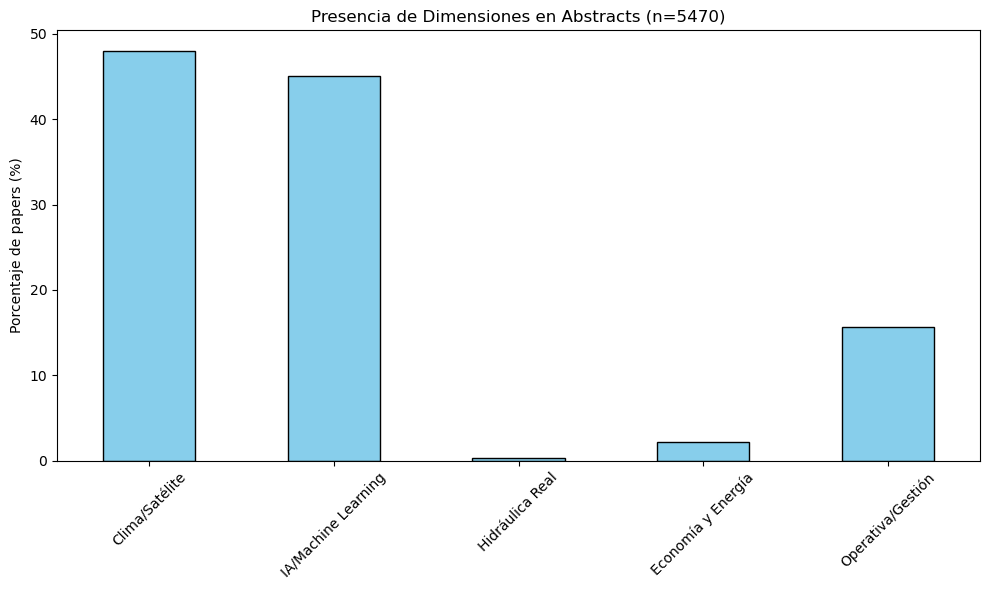

In [13]:
# Diccionario de dimensiones y términos asociados
dimensiones = {
    "Clima/Satélite": ["satellite", "ndvi", "evapotranspiration", "weather"],
    "IA/Machine Learning": ["lstm", "random forest", "neural network", "iot", "sensor"],
    "Hidráulica Real": ["uniformity coefficient", "hydraulic degradation", "pressure drop", "emitter clogging", "drip system evaluation"],
    "Economía y Energía": ["pumping cost", "electricity cost", "energy efficiency", "economic return", "roi", "water cost"],
    "Operativa/Gestión": ["process optimization", "decision support system", "governance", "iso", "maintenance"]
}

# Inicializar columnas booleanas
for dim, terms in dimensiones.items():
    articulos[dim] = articulos['Abstract'].str.lower().apply(
        lambda x: any(term in str(x) for term in terms)
    )

# Calcular porcentajes
porcentajes = articulos[list(dimensiones.keys())].mean() * 100
print(porcentajes)

# Gráfico de barras
plt.figure(figsize=(10,6))
porcentajes.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Presencia de Dimensiones en Abstracts (n=5470)")
plt.ylabel("Porcentaje de papers (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Limpieza preliminar para el equipo (Excel de Cribado PRISMA)

Generar una versión filtrada en Excel (.xlsx) libre de duplicados y ordenada por número de citas, agregando una columna vacía llamada "Elegible_PRISMA (Sí/No)" y otra llamada "Dimensión_Principal" para que el equipo comience la revisión visual de títulos y resúmenes."

In [15]:
# Eliminar duplicados
articulos_filtrados = articulos.drop_duplicates(subset=["DOI", "Title"], keep="first")

# Convertir 'Cited by' a numérico (forzando errores a NaN si hay valores no numéricos)
articulos_filtrados["Cited by"] = pd.to_numeric(articulos_filtrados["Cited by"], errors="coerce")

# Ordenar por número de citas (descendente)
articulos_filtrados = articulos_filtrados.sort_values(by="Cited by", ascending=False)

# Agregar columnas vacías
articulos_filtrados["Elegible_PRISMA (Sí/No)"] = ""
articulos_filtrados["Dimensión_Principal"] = ""

# Exportar a Excel
articulos_filtrados.to_excel("scopus_filtrado.xlsx", index=False)